In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Locate the exported forecast results.
forecast_dir = Path("../outputs/forecast")

sensitivity_df = pd.read_csv(
    forecast_dir / "appearance_sensitivity_paths.csv",
    parse_dates=["milestone_date"],
)

sensitivity_summary = pd.read_csv(
    forecast_dir / "appearance_sensitivity_summary.csv",
)

monthly_df = pd.read_csv(
    forecast_dir / "monthly_milestone_probabilities.csv",
    parse_dates=["deadline"],
)

# Validate the imported data.
assert len(sensitivity_df) == 3000
assert len(sensitivity_summary) == 3
assert len(monthly_df) == 27

assert sensitivity_df.groupby("scenario").size().eq(1000).all()

print("FORECAST DATA LOADED SUCCESSFULLY")
print("=" * 55)
print(f"Simulation paths: {len(sensitivity_df):,}")
print(f"Appearance scenarios: {len(sensitivity_summary)}")
print(f"Monthly probability records: {len(monthly_df)}")

print("\nScenarios:")
print(sensitivity_df["scenario"].value_counts().to_string())

print("\nData validation: PASSED")

FORECAST DATA LOADED SUCCESSFULLY
Simulation paths: 3,000
Appearance scenarios: 3
Monthly probability records: 27

Scenarios:
scenario
Conservative    1000
Baseline        1000
Optimistic      1000

Data validation: PASSED


## Cumulative milestone probability chart

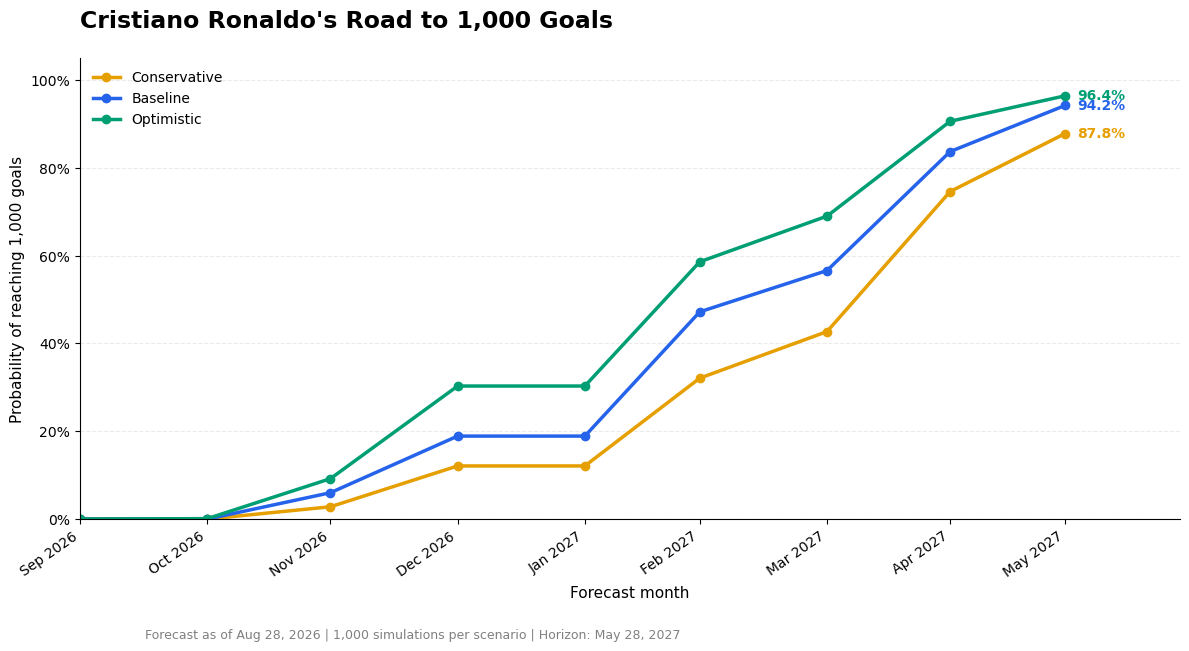

Chart saved: ..\outputs\forecast\01_monthly_milestone_probability.png


In [4]:
# Visualize cumulative milestone probabilities

from matplotlib.ticker import PercentFormatter

scenario_order = ["Conservative", "Baseline", "Optimistic"]

plot_data = monthly_df.pivot(
    index="deadline",
    columns="scenario",
    values="probability",
)[scenario_order].sort_index()

fig, ax = plt.subplots(figsize=(12, 6.5))

colors = {
    "Conservative": "#E69F00",
    "Baseline": "#2563EB",
    "Optimistic": "#009E73",
}

for scenario in scenario_order:
    ax.plot(
        plot_data.index,
        plot_data[scenario],
        marker="o",
        markersize=6,
        linewidth=2.5,
        color=colors[scenario],
        label=scenario,
    )

    # Label each scenario at the final forecast date.
    ax.annotate(
        f"{plot_data[scenario].iloc[-1]:.1%}",
        xy=(plot_data.index[-1], plot_data[scenario].iloc[-1]),
        xytext=(9, 0),
        textcoords="offset points",
        va="center",
        fontsize=10,
        fontweight="bold",
        color=colors[scenario],
    )

ax.set_title(
    "Cristiano Ronaldo's Road to 1,000 Goals",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=22,
)

ax.set_xlabel("Forecast month", fontsize=11)
ax.set_ylabel("Probability of reaching 1,000 goals", fontsize=11)

ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.set_ylim(0, 1.05)
ax.set_xlim(
    plot_data.index.min(),
    plot_data.index.max() + pd.Timedelta(days=28),
)

ax.set_xticks(plot_data.index)
ax.set_xticklabels(
    plot_data.index.strftime("%b %Y"),
    rotation=35,
    ha="right",
)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper left")

fig.text(
    0.125,
    0.01,
    "Forecast as of Aug 28, 2026 | 1,000 simulations per scenario | "
    "Horizon: May 28, 2027",
    fontsize=9,
    color="gray",
)

plt.tight_layout(rect=[0, 0.045, 1, 1])

chart_path = forecast_dir / "01_monthly_milestone_probability.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {chart_path}")

## Milestone-date distributions

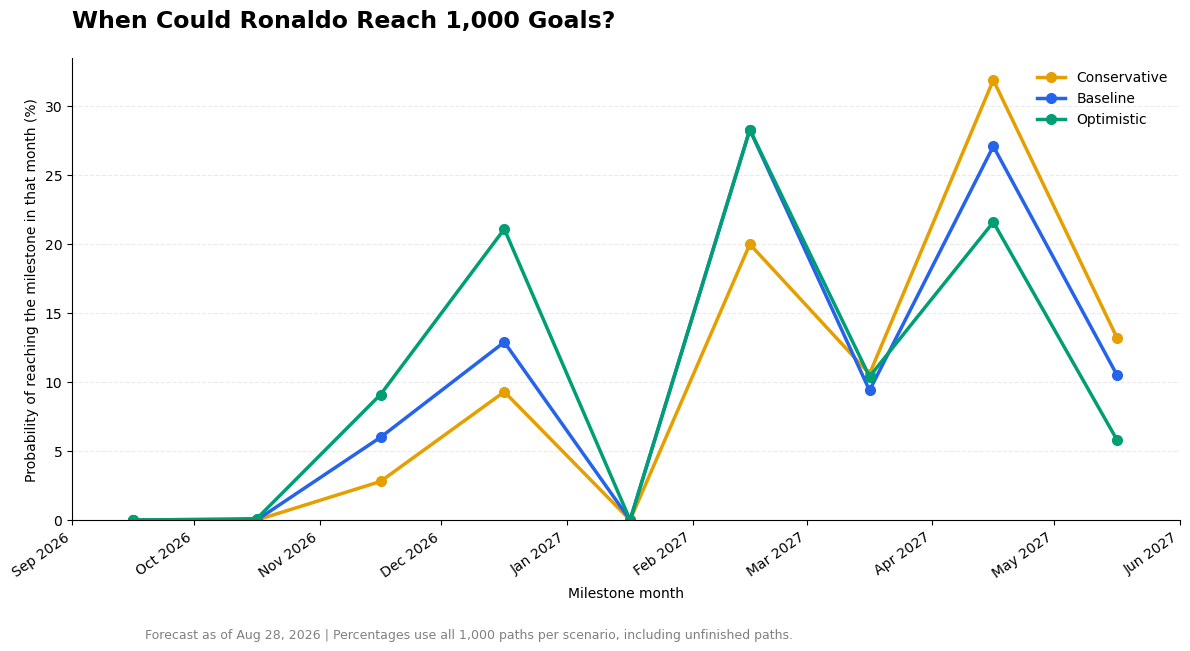

Chart saved: ..\outputs\forecast\02_milestone_date_distribution.png


In [13]:
# Visualize milestone-date distributions

import matplotlib.dates as mdates

scenario_order = ["Conservative", "Baseline", "Optimistic"]

month_edges = pd.date_range(
    "2026-09-01",
    "2027-06-01",
    freq="MS",
)

fig, ax = plt.subplots(figsize=(12, 6.5))

for scenario in scenario_order:
    dates = sensitivity_df.loc[
        (sensitivity_df["scenario"] == scenario)
        & sensitivity_df["milestone_reached"],
        "milestone_date",
    ].dropna()

    monthly_counts = pd.cut(
        dates,
        bins=month_edges,
        right=False,
    ).value_counts(sort=False)

    monthly_probabilities = monthly_counts.to_numpy() / 1000 * 100

    month_centers = month_edges[:-1] + (
        month_edges[1:] - month_edges[:-1]
    ) / 2

    ax.plot(
        month_centers,
        monthly_probabilities,
        marker="o",
        linewidth=2.5,
        markersize=7,
        color=colors[scenario],
        label=scenario,
    )

ax.set_title(
    "When Could Ronaldo Reach 1,000 Goals?",
    fontsize=17,
    fontweight="bold",
    loc="left",
    pad=22,
)

ax.set_xlabel("Milestone month")
ax.set_ylabel("Probability of reaching the milestone in that month (%)")

ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

ax.set_xlim(month_edges[0], month_edges[-1])
ax.set_ylim(bottom=0)

ax.grid(axis="y", linestyle="--", alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)

plt.xticks(rotation=35, ha="right")

fig.text(
    0.125,
    0.01,
    "Forecast as of Aug 28, 2026 | Percentages use all 1,000 paths "
    "per scenario, including unfinished paths.",
    fontsize=9,
    color="gray",
)

plt.tight_layout(rect=[0, 0.045, 1, 1])

chart_path = forecast_dir / "02_milestone_date_distribution.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {chart_path}")

## Appearance-sensitivity comparison

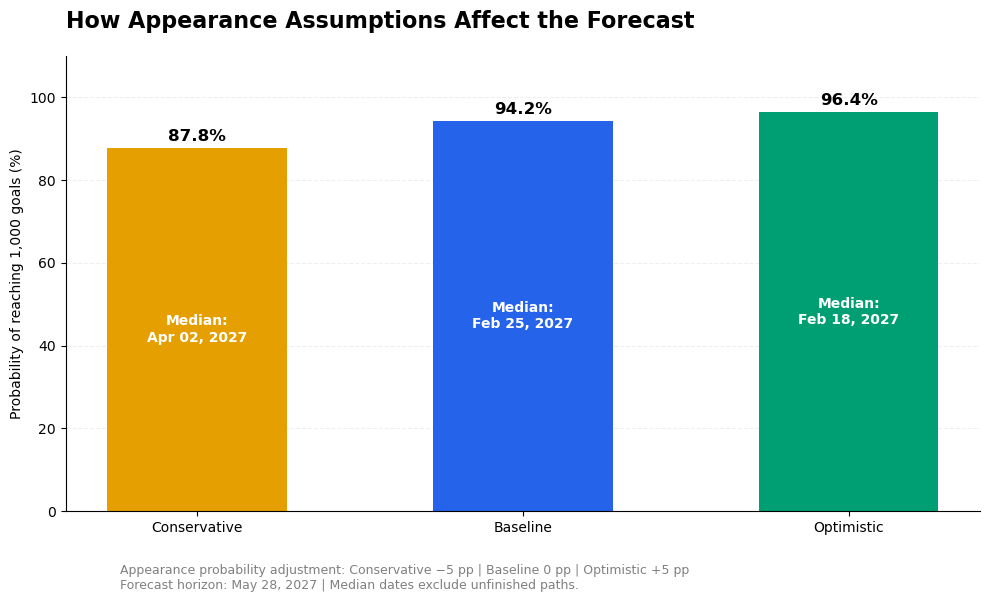

Chart saved: ..\outputs\forecast\03_appearance_sensitivity.png


In [16]:
# Visualize appearance sensitivity

scenario_order = ["Conservative", "Baseline", "Optimistic"]

summary = (
    sensitivity_summary
    .set_index("scenario")
    .loc[scenario_order]
    .copy()
)

summary["median_date"] = pd.to_datetime(summary["median_date"])

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    summary.index,
    summary["completion_probability"] * 100,
    color=[colors[scenario] for scenario in scenario_order],
    width=0.55,
)

for bar, (_, row) in zip(bars, summary.iterrows()):
    probability = row["completion_probability"] * 100

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        probability + 1,
        f"{probability:.1f}%",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold",
    )

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        probability / 2,
        f"Median:\n{row['median_date']:%b %d, %Y}",
        ha="center",
        va="center",
        fontsize=10,
        color="white",
        fontweight="bold",
    )

ax.set_title(
    "How Appearance Assumptions Affect the Forecast",
    fontsize=16,
    fontweight="bold",
    loc="left",
    pad=20,
)

ax.set_ylabel("Probability of reaching 1,000 goals (%)")
ax.set_ylim(0, 110)

ax.grid(axis="y", linestyle="--", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)

fig.text(
    0.125,
    0.01,
    "Appearance probability adjustment: Conservative −5 pp | "
    "Baseline 0 pp | Optimistic +5 pp\n"
    "Forecast horizon: May 28, 2027 | Median dates exclude unfinished paths.",
    fontsize=9,
    color="gray",
)

plt.tight_layout(rect=[0, 0.075, 1, 1])

chart_path = forecast_dir / "03_appearance_sensitivity.png"

fig.savefig(
    chart_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print(f"Chart saved: {chart_path}")